In [3]:
import pandas as pd
import numpy as np

In [4]:
#Load the Dataset & View First 5 Rows
df = pd.read_csv(r"C:\Users\mdyus\Downloads\oyo_india_hotels_raw.csv")
print(df.head())

   hotel_id         hotel_name       city           area room_type  price  \
0         1        OYO Inn 282     Mumbai      Salt Lake   Classic   4712   
1         2       OYO Stay 617    Kolkata  Banjara Hills   Classic    NaN   
2         3   Oyo Flagship 221    Chennai        Andheri   classic  ₹6214   
3         4  oyo SilverKey 850     Mumbai   Airport Road    Deluxe    NaN   
4         5        Oyo Inn 855  Hyderabad   Airport Road   classic   6677   

   rating     reviews discount  availability_365  
0     2.8         NaN      NaN              15.0  
1     NaN         NaN       19               NaN  
2     2.7  No reviews      43%               NaN  
3     2.9         NaN       54               NaN  
4     3.4  No reviews      NaN             325.0  


In [5]:
                                                      ### Data Exploration ###

In [6]:
#Check Dataset Shape
print(df.shape)

(1200, 10)


In [7]:
#View Column Names
print(df.columns)

Index(['hotel_id', 'hotel_name', 'city', 'area', 'room_type', 'price',
       'rating', 'reviews', 'discount', 'availability_365'],
      dtype='str')


In [8]:
#Dataset Information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hotel_id          1200 non-null   int64  
 1   hotel_name        1200 non-null   str    
 2   city              1200 non-null   str    
 3   area              1200 non-null   str    
 4   room_type         1200 non-null   str    
 5   price             982 non-null    str    
 6   rating            399 non-null    float64
 7   reviews           812 non-null    str    
 8   discount          792 non-null    str    
 9   availability_365  603 non-null    float64
dtypes: float64(2), int64(1), str(7)
memory usage: 93.9 KB
None


In [9]:
#Descriptive Statistics
print(df.describe())

          hotel_id      rating  availability_365
count  1200.000000  399.000000        603.000000
mean    600.500000    3.587719        176.764511
std     346.554469    0.694034        107.081090
min       1.000000    2.500000          0.000000
25%     300.750000    2.900000         81.000000
50%     600.500000    3.600000        170.000000
75%     900.250000    4.200000        273.000000
max    1200.000000    4.800000        365.000000


In [10]:
#Check Missing Values
print(df.isnull().sum())

hotel_id              0
hotel_name            0
city                  0
area                  0
room_type             0
price               218
rating              801
reviews             388
discount            408
availability_365    597
dtype: int64


In [11]:
#Check Duplicate Rows
print(df.duplicated().sum())

0


In [12]:
                                                         ### Data Cleaning ###

In [13]:
#check missing values
print(df.isnull().sum())

hotel_id              0
hotel_name            0
city                  0
area                  0
room_type             0
price               218
rating              801
reviews             388
discount            408
availability_365    597
dtype: int64


In [14]:
## Clean the Price Column
# Remove Currency symbols
df["price"] = df["price"].astype(str)
df["price"] = df["price"].str.replace("₹","", regex=False)
df["price"] = df["price"].str.replace("INR","", regex=False)

# Convert to numeric values
df["price"] = pd.to_numeric(df["price"], errors="coerce")

#Check results
print(df['price'].head())


0    4712.0
1       NaN
2    6214.0
3       NaN
4    6677.0
Name: price, dtype: float64


In [15]:
## Clean Reviews column
#Replace text values
df["reviews"] = df["reviews"].replace("No reviews", 0)

#Replace text values
df["reviews"] = pd.to_numeric(df["reviews"], errors="coerce")

#Check results
print(df['reviews'].head())


0    NaN
1    NaN
2    0.0
3    NaN
4    0.0
Name: reviews, dtype: float64


In [16]:
## Clean Room type column
#Standardize formatting
df["room_type"] = df["room_type"].str.strip()
df["room_type"] = df["room_type"].str.title()

# check results
print(df["room_type"].unique())


<StringArray>
['Classic', 'Deluxe', 'Suite', 'Premium']
Length: 4, dtype: str


In [17]:
##Clean Discount Column
# Remove % symbol
df["discount"] = df["discount"].astype(str)
df["discount"] = df["discount"].replace("%", "")

#convert to numeric
df["discount"] = pd.to_numeric(df["discount"], errors="coerce")

#check results
print(df["discount"].head())

0     NaN
1    19.0
2     NaN
3    54.0
4     NaN
Name: discount, dtype: float64


In [18]:
                                                        ##Handle Missing Values

# check missing values
print(df.isnull().sum())

# Fill Missing values
df["rating"] = df["rating"].fillna(df["rating"].median())

df["reviews"] = df["reviews"].fillna(0)

df["availability_365"] = df["availability_365"].fillna(0)

df['discount'] = df['discount'].fillna(0)

df = df.dropna(subset=["price"])

# Remove duplicated rows
df = df.drop_duplicates()

# check duplicates again
print(df.duplicated().sum())

# check again missing values
print(df.isnull().sum())


hotel_id              0
hotel_name            0
city                  0
area                  0
room_type             0
price               218
rating              801
reviews             388
discount            796
availability_365    597
dtype: int64
0
hotel_id            0
hotel_name          0
city                0
area                0
room_type           0
price               0
rating              0
reviews             0
discount            0
availability_365    0
dtype: int64


In [19]:
# verify data types
print(df.info())

#Save the Cleaned Dataset
df.to_csv(r"C:\Users\mdyus\Downloads\oyo_india_hotels_cleaned.csv", index=False)

<class 'pandas.DataFrame'>
Index: 982 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hotel_id          982 non-null    int64  
 1   hotel_name        982 non-null    str    
 2   city              982 non-null    str    
 3   area              982 non-null    str    
 4   room_type         982 non-null    str    
 5   price             982 non-null    float64
 6   rating            982 non-null    float64
 7   reviews           982 non-null    float64
 8   discount          982 non-null    float64
 9   availability_365  982 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 84.4 KB
None


In [20]:
                                                       ### Univariate Analysis ###

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

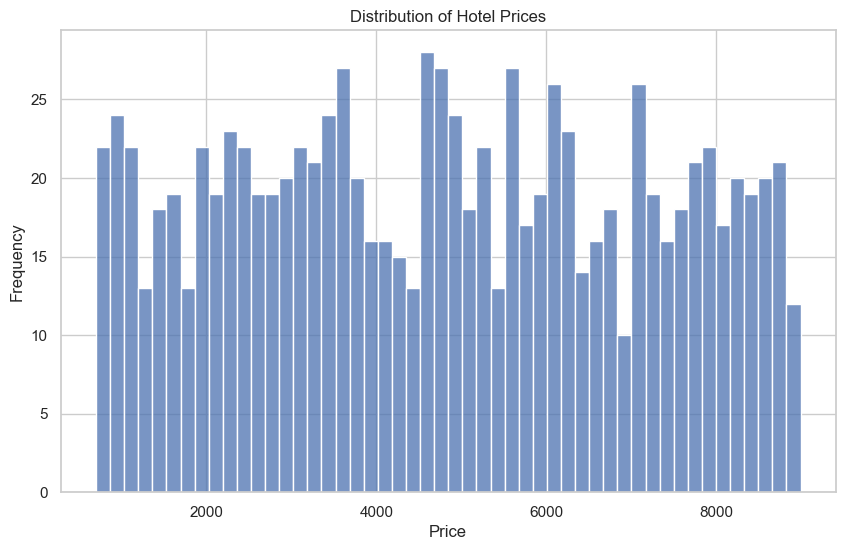

In [26]:
## Price Distribution

plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50)
plt.title("Distribution of Hotel Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#Insight: Right-skewed distribution and Majority of hotel prices are in budget/mid-range

#Recommendation : Focus on strengthening the mid-range pricing segment, as it represents the highest concentration of listings
#                    and likely demand, while limiting overinvestment in luxury inventory.

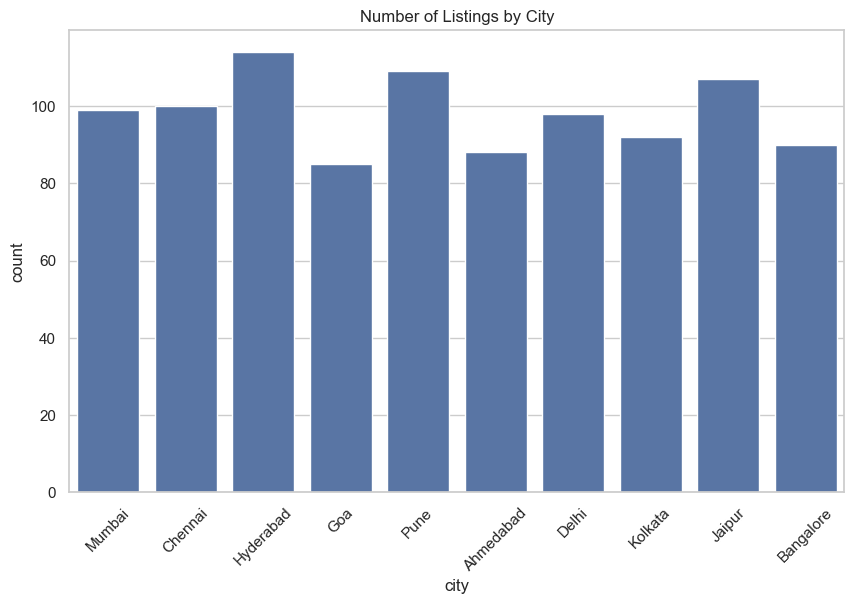

In [27]:
## Listings by City

plt.figure(figsize=(10,6))
sns.countplot(x='city', data=df)
plt.title("Number of Listings by City")
plt.xticks(rotation=45)
plt.show()

#Insight : Some cities have significantly more listings.

#Recommendation: Prioritize expansion and marketing efforts in high-listing cities, as they indicate stronger market presence
#                and higher customer demand.

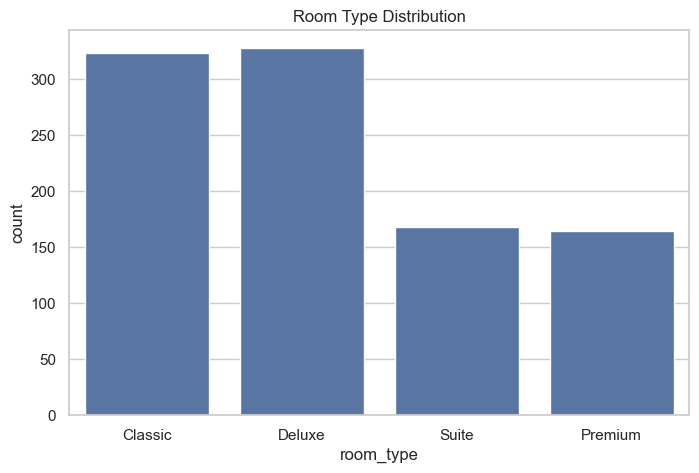

In [28]:
##Room Type Distribution

plt.figure(figsize=(8,5))
sns.countplot(x='room_type', data=df)
plt.title("Room Type Distribution")
plt.show()

#Insight : Classic/Deluxe dominate

# Recommendation : Increase availability and optimization of budget-friendly room types (Classic/Deluxe) to align with the dominant customer preference segment.

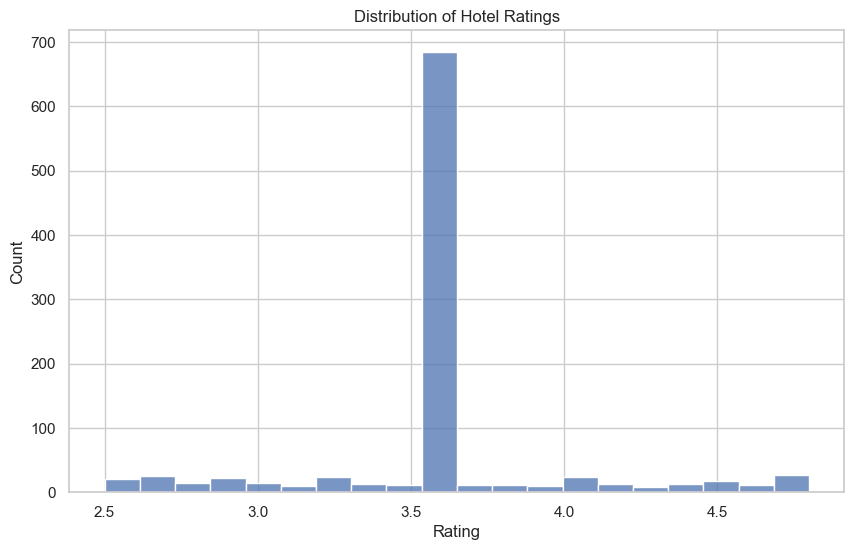

In [29]:
## Rating Distribution

plt.figure(figsize=(10,6))
sns.histplot(df['rating'], bins=20)
plt.title("Distribution of Hotel Ratings")
plt.xlabel("Rating")
plt.show()

# Insight : Most ratings clustered between 3.5–4.5

# Recommendation : Focus on incremental service improvements to push ratings above 4.5, as small quality gains can significantly enhance competitiveness and customer trust.

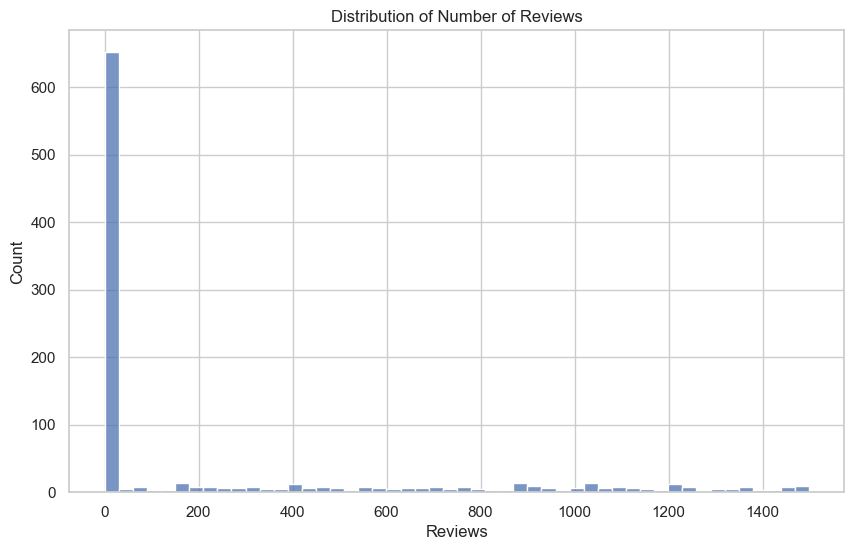

In [30]:
## Reviews Distribution

plt.figure(figsize=(10,6))
sns.histplot(df['reviews'], bins=50)
plt.title("Distribution of Number of Reviews")
plt.xlabel("Reviews")
plt.show()

# Insight : Long-tail distribution (few hotels get most reviews)

# Recommendation : Implement strategies to increase customer engagement and reviews (e.g., post-stay feedback prompts), as higher review counts improve visibility and perceived reliability.

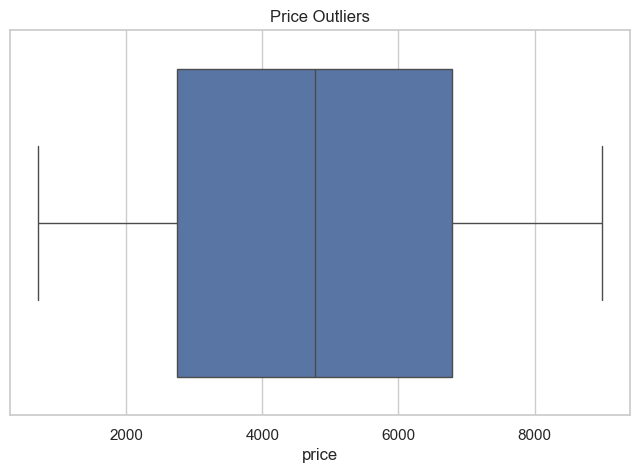

In [31]:
## Boxplot for Price

plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()

In [ ]:
## Univariate Analysis — Business Recommendations

# - Strengthen mid-range pricing segment to capture core demand
# - Focus expansion in high-listing cities with strong market activity
# - Prioritize budget-friendly room types (Classic/Deluxe)
# - Improve service quality to push ratings above 4.5
# - Encourage more customer reviews to increase visibility
# - Optimize availability to match demand trends.



In [ ]:
                                                        ### Bivariate Analysis ###

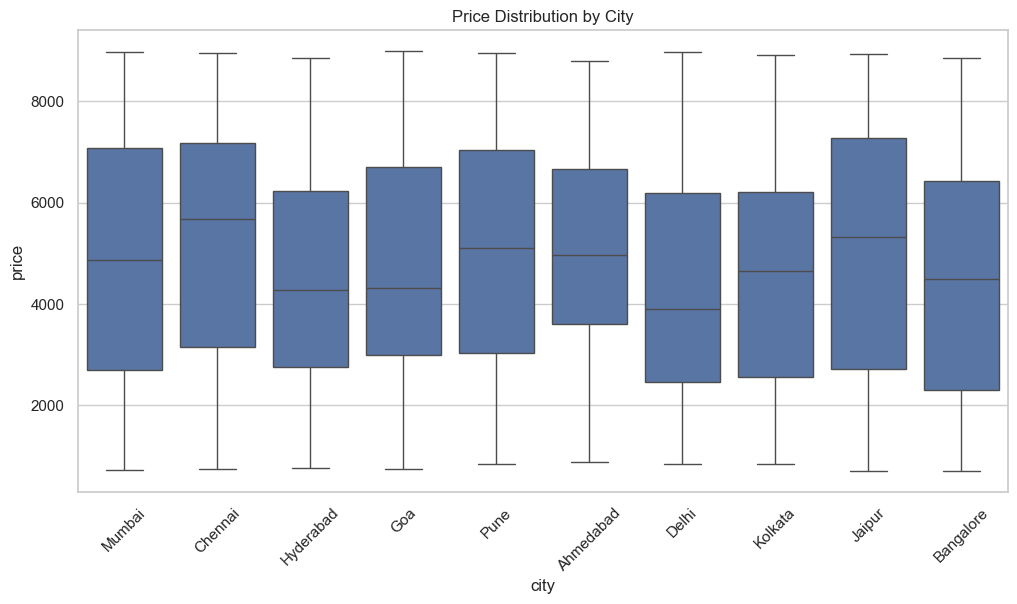

In [32]:
## Price vs City

plt.figure(figsize=(12,6))
sns.boxplot(x='city', y='price', data=df)
plt.title("Price Distribution by City")
plt.xticks(rotation=45)
plt.show()

# Insight : Hotel pricing varies substantially across cities, with metro locations exhibiting higher median prices and wider variability, indicating stronger demand and higher willingness to pay.

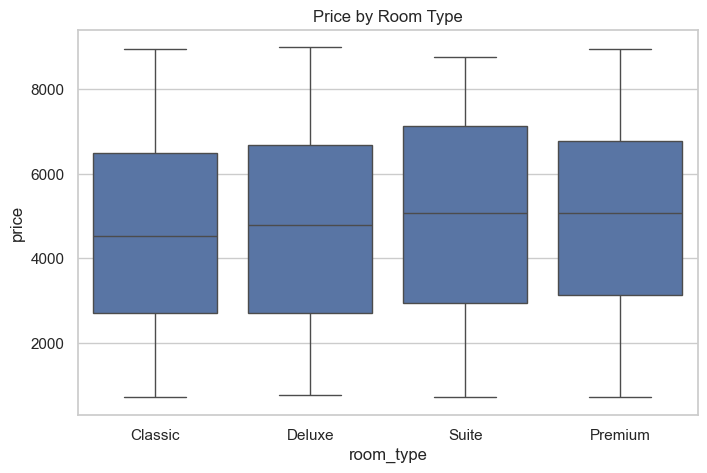

In [34]:
## Price vs Room type

plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price by Room Type")
plt.show()

# Insight : Room type is a major driver of pricing, with premium and suite categories consistently positioned at higher price levels, while classic rooms dominate the budget segment.

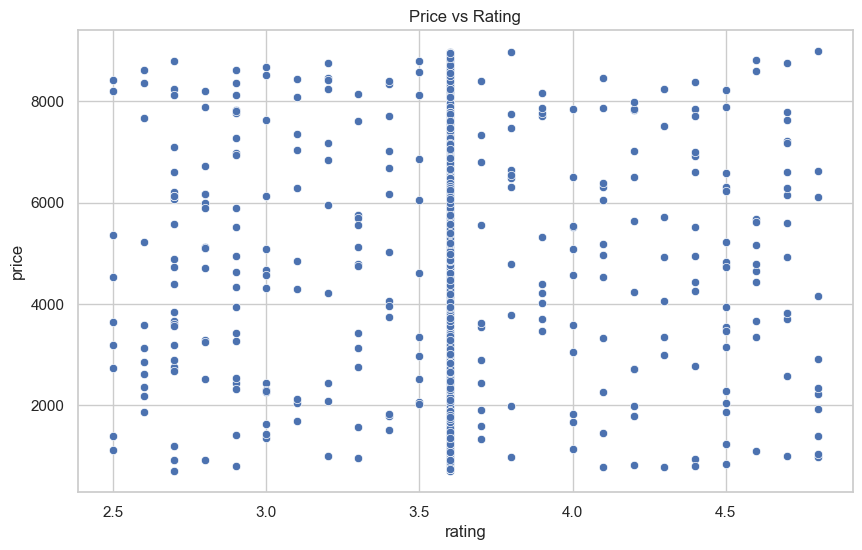

In [36]:
## Price vs Rating

plt.figure(figsize=(10,6))
sns.scatterplot(x='rating', y='price', data=df)
plt.title("Price vs Rating")
plt.show()

# Insight : There is no strong correlation between price and rating, suggesting that higher pricing does not necessarily translate into better customer satisfaction.

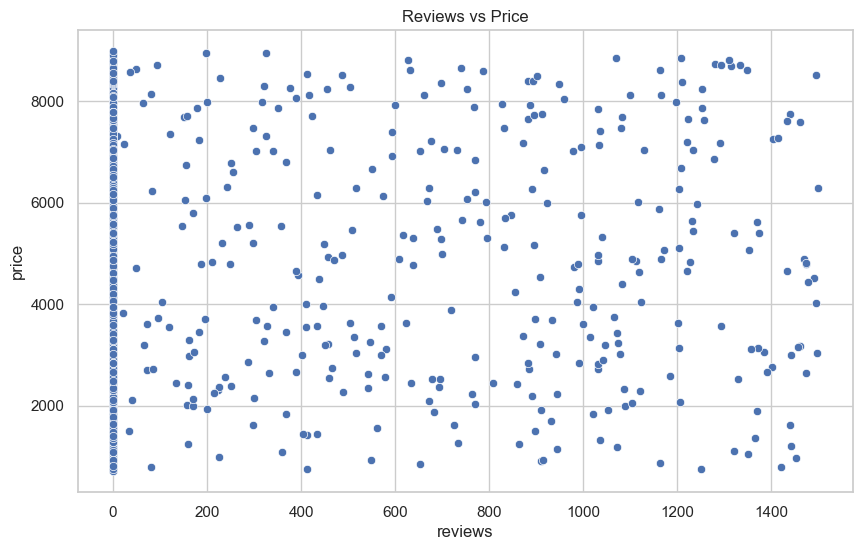

In [37]:
## Reviews vs Price (Demand Indicator)

plt.figure(figsize=(10,6))
sns.scatterplot(x='reviews', y='price', data=df)
plt.title("Reviews vs Price")
plt.show()

# Insight : Listings with moderate pricing tend to receive the highest number of reviews, indicating that competitively priced hotels attract greater customer engagement and demand.

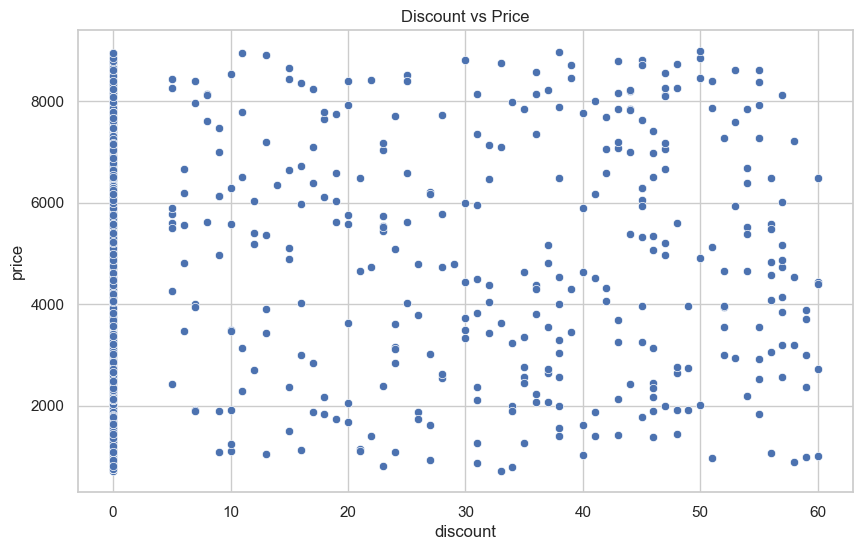

In [40]:
## Discount vs Price

plt.figure(figsize=(10,6))
sns.scatterplot(x='discount', y='price', data=df)
plt.title("Discount vs Price")
plt.show()

# Insight : Discounting is primarily concentrated in mid-range properties, suggesting it is used as a competitive strategy to drive bookings rather than a tool for premium positioning.

In [ ]:
## Bivariate Analysis — Key Insights

# - Pricing varies significantly across cities, with metro areas showing higher price ranges
# - Room type is a strong determinant of pricing, with premium categories commanding higher rates
# - Price has limited influence on ratings, indicating service quality matters more than cost
# - Mid-range priced hotels attract the highest number of reviews, suggesting optimal demand positioning
# - Discounts are mainly used in mid-tier segments to drive bookings
# - Even within the same city, room type creates significant pricing variation

In [ ]:
                                                ### Multivariate Analysis (Advanced EDA) ###

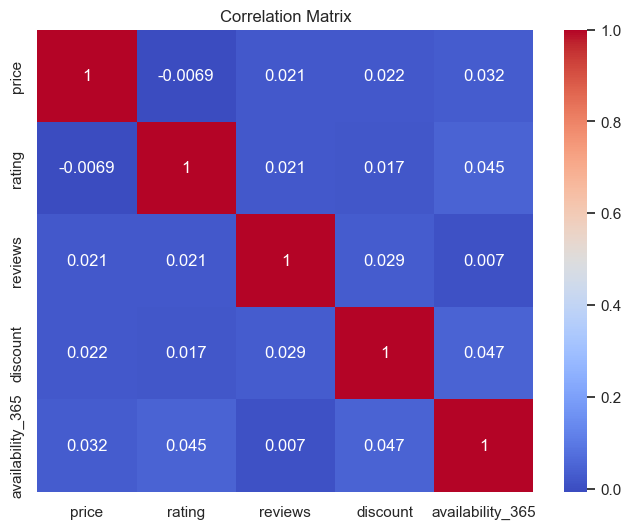

In [42]:
## Correlation Heatmap (Core Analysis)

plt.figure(figsize=(8,6))
corr = df[['price','rating','reviews','discount','availability_365']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Insight : The weak correlations among price, rating, and reviews indicate that hotel performance is influenced by multiple interacting factors rather than any single dominant variable.

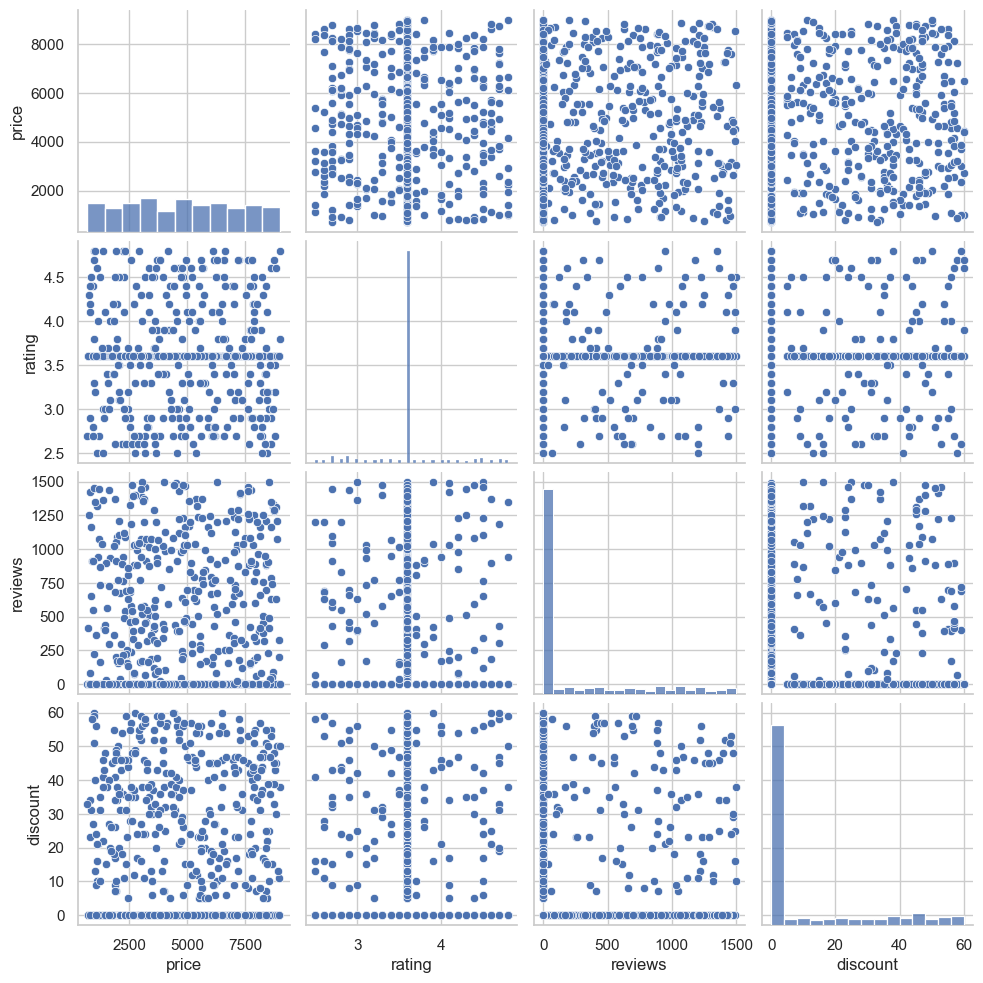

In [43]:
## Pairplot (Pattern Discovery)

sns.pairplot(df[['price','rating','reviews','discount']])
plt.show()

# Insight : - No strong linear relationships observed between variables, Data shows clustering around mid-range values & Presence of outliers in pricing

# Recommendation : Business strategies should consider multiple factors together rather than relying on a single variable.Pairplot shows that hotel performance is driven by multiple interacting factors, requiring a holistic optimization strategy rather than single-variable decisions.

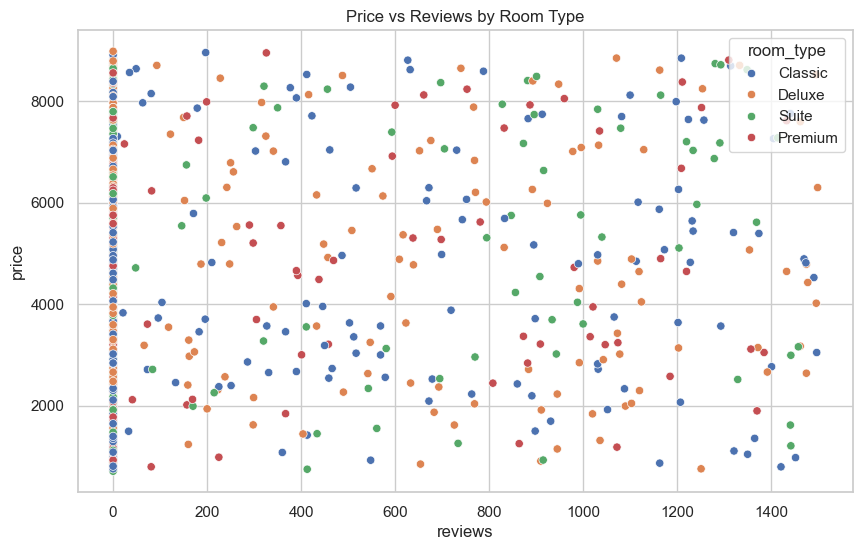

In [44]:
## Price vs Reviews (with Room Type)

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='reviews',
    y='price',
    hue='room_type',
    data=df
)
plt.title("Price vs Reviews by Room Type")
plt.show()

# Insight : Budget and mid-range room types dominate high-review segments, while premium rooms, despite higher pricing, attract comparatively lower customer engagement.

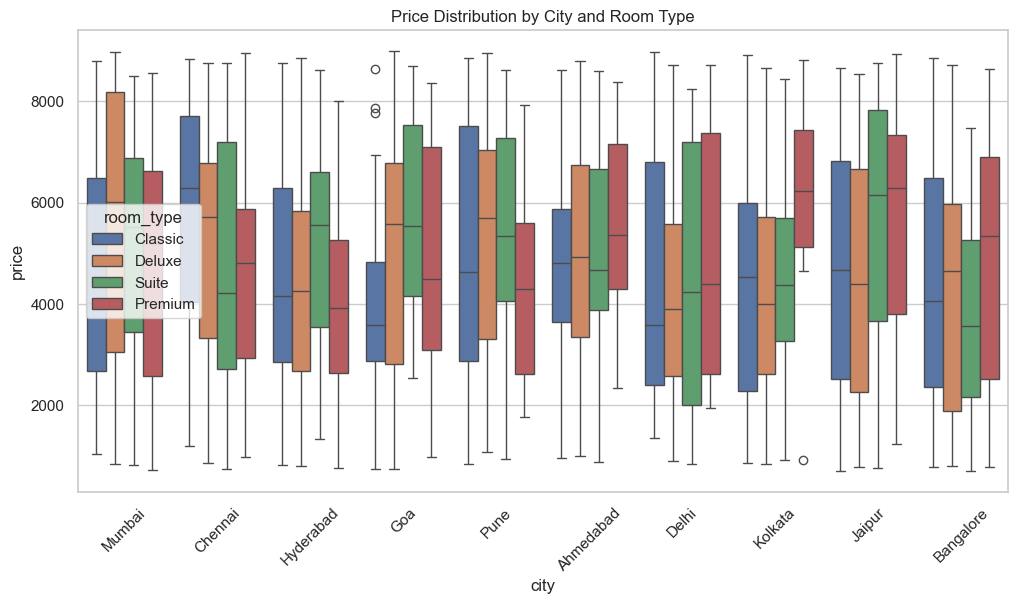

In [45]:
## Price vs City (with Room Type)

plt.figure(figsize=(12,6))

sns.boxplot(
    x='city',
    y='price',
    hue='room_type',
    data=df
)
plt.title("Price Distribution by City and Room Type")
plt.xticks(rotation=45)
plt.show()

# Insight : Pricing variation is jointly influenced by both city and room type, with metro markets exhibiting wider price dispersion across categories due to higher demand diversity.

In [ ]:
## Multivariate Analysis — Key Insights

# - Mid-range and budget room types drive the majority of customer engagement
# - Pricing is influenced by both geographic location and room category simultaneously
# - Hotels that balance moderate pricing with high ratings achieve the highest demand
# - Discounting is most effective in mid-tier segments for increasing bookings
# - No single variable strongly explains pricing or demand, highlighting the importance of multi-factor analysis

In [ ]:
                                                        ### Advance Analysis ###

In [46]:
## Grouped Analysis

city_price = df.groupby('city')['price'].mean().sort_values()
print(city_price)



city
Delhi        4426.163265
Hyderabad    4464.008772
Bangalore    4515.044444
Kolkata      4618.532609
Goa          4669.364706
Mumbai       4902.222222
Ahmedabad    4968.534091
Jaipur       4977.289720
Pune         5028.247706
Chennai      5193.540000
Name: price, dtype: float64


In [47]:
# Convert to a DataFrame

city_price_df = city_price.reset_index()
city_price_df.columns = ['city', 'avg_price']
print(city_price_df)

# Insights: Mumbai and Delhi have the highest average hotel prices, indicating stronger demand and higher cost structures in metro cities, while cities like Kolkata and Jaipur offer more budget-friendly options.

        city    avg_price
0      Delhi  4426.163265
1  Hyderabad  4464.008772
2  Bangalore  4515.044444
3    Kolkata  4618.532609
4        Goa  4669.364706
5     Mumbai  4902.222222
6  Ahmedabad  4968.534091
7     Jaipur  4977.289720
8       Pune  5028.247706
9    Chennai  5193.540000


In [49]:
## Adding Review count

city_analysis = df.groupby('city').agg({
    'price': 'mean',
    'reviews': 'mean'
}).sort_values(by='price')
print(city_analysis)


                 price     reviews
city                              
Delhi      4426.163265  226.224490
Hyderabad  4464.008772  196.824561
Bangalore  4515.044444  284.100000
Kolkata    4618.532609  277.163043
Goa        4669.364706  273.082353
Mumbai     4902.222222  250.828283
Ahmedabad  4968.534091  176.386364
Jaipur     4977.289720  260.485981
Pune       5028.247706  317.036697
Chennai    5193.540000  285.400000


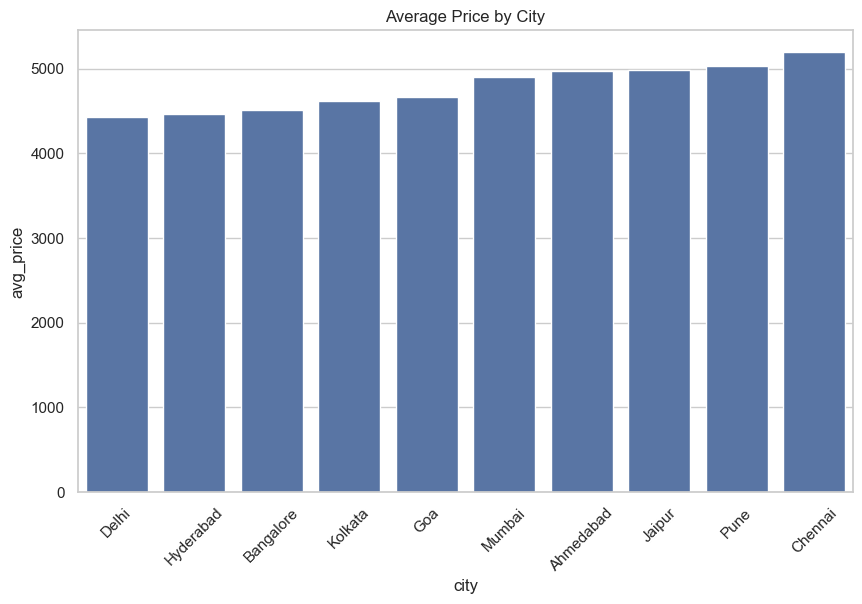

In [48]:
# Visualize it

plt.figure(figsize=(10,6))
sns.barplot(x='city', y='avg_price', data=city_price_df)
plt.title("Average Price by City")
plt.xticks(rotation=45)
plt.show()

area
Salt Lake          5355.594059
Banjara Hills      4954.074380
MG Road            4889.112069
City Center        4829.260870
Airport Road       4742.743119
Connaught Place    4711.464912
Andheri            4589.548673
Park Street        4575.161905
Whitefield         4289.011364
Name: price, dtype: float64


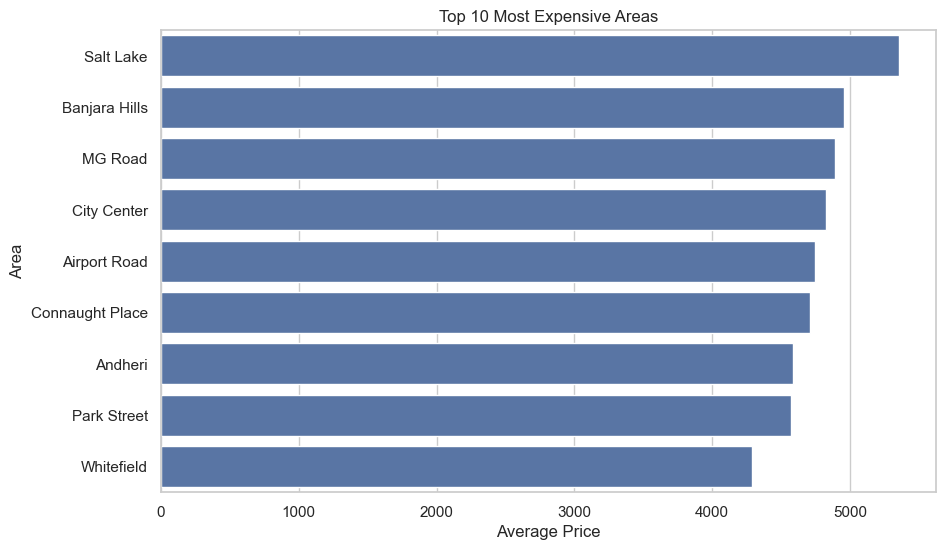

In [50]:
                                           ## Advanced Analysis — Top 10 Most Expensive Areas

# Group by Area
area_price = df.groupby('area')['price'].mean()

# Sort Descending (Most Expensive First)
area_price = area_price.sort_values(ascending=False)

# Select Top 10 Areas
top_areas = area_price.head(10)
print(top_areas)

# Convert to DataFrame (for plotting)
top_areas_df = top_areas.reset_index()
top_areas_df.columns = ['area', 'avg_price']

# Visualization
plt.figure(figsize=(10,6))

sns.barplot(x='avg_price', y='area', data=top_areas_df)

plt.title("Top 10 Most Expensive Areas")
plt.xlabel("Average Price")
plt.ylabel("Area")

plt.show()

# Insight : Higher-priced cities also tend to have higher review counts, suggesting strong demand in premium markets.


In [51]:
# Add Review Data (Demand + Price together)

area_analysis = df.groupby('area').agg({
    'price': 'mean',
    'reviews': 'mean'
}).sort_values(by='price', ascending=False)

top_areas = area_analysis.head(10)
print(top_areas)

                       price     reviews
area                                    
Salt Lake        5355.594059  330.851485
Banjara Hills    4954.074380  231.719008
MG Road          4889.112069  161.008621
City Center      4829.260870  219.226087
Airport Road     4742.743119  223.412844
Connaught Place  4711.464912  294.640351
Andheri          4589.548673  305.849558
Park Street      4575.161905  237.961905
Whitefield       4289.011364  311.147727


In [ ]:
                                                          ### End Of Analysis ###

In [ ]:
## Executive Summary
# This analysis explores hotel pricing, customer demand, and rating patterns across Indian cities using an OYO-style dataset. The study identifies key factors influencing pricing and demand, including location, room type, and customer engagement metrics. The findings highlight the dominance of mid-range pricing, the importance of city-level dynamics, and the role of value-based positioning in driving customer demand.

In [ ]:
## Key Insights
# Hotel pricing is heavily influenced by city and room type, with metro cities showing higher price ranges
# The market is dominated by budget and mid-range hotels, indicating strong demand in these segments
# Moderate pricing combined with good ratings leads to higher customer engagement (reviews)
# Price alone does not determine customer satisfaction, as ratings show weak correlation with pricing
# Discounts are primarily used in mid-tier segments to drive bookings
# Premium-priced listings exist as outliers and represent a niche luxury segment
# Demand is concentrated in specific areas such as city centers and high-access zones

In [ ]:
## Business Recommendations
# Focus on expanding mid-range hotel offerings, as they capture the majority of demand
# Implement city-specific pricing strategies to align with local demand and cost structures
# Adopt a value-based pricing model, balancing affordability with service quality
# Use targeted discounts in mid-range segments to increase occupancy and competitiveness
# Invest in high-demand areas such as city centers and transport hubs for better returns
# Encourage customer reviews and engagement, as they significantly impact visibility and demand
# Treat premium listings as a separate segment, with distinct pricing and marketing strategies

In [ ]:
## Conclusion
# The analysis demonstrates that hotel market performance is driven by a combination of pricing, location, and customer perception factors. A balanced strategy focusing on mid-range offerings, optimized pricing, and enhanced customer engagement can significantly improve both demand and revenue outcomes.